In [1]:
# * Imports

import numpy as np
import matplotlib.pyplot as plt  # * For Plotting
import scipy as sp
from scipy import integrate  # * For Solving Differential Equations
import snoop  # * For Debugging Purpose

# from scipy.optimize import brentq
from numbalsoda import lsoda_sig, lsoda  # Faster Method
# from NumbaMinpack import lmdif, hybrd, minpack_sig
import numba as nb  # For Speeding Up
import scipy.integrate as integrate

In [2]:
# Parameters

mu = 1.0  #! This Value was not given in paper. I solved it
#! using the constraint on the total energy
M = 1.0
L = 1.0
z0 = 0.5
alpha = 0.01  # TODO Important Parameter.
ics = np.array(
    [1.2, 0.0, 0.0, 0.0, 0.76, L]
)  # * Initial conditions w,z,phi, pw,pz,pphi from paper
t = np.arange(0.0, 100000.0, 1)  # Time Steps for evolution

tau = 100  # Renormalization time
tf = 1000000.0  # Final time
steps = 10000  # *Number of time steps between each time interval
# Theory Parameters

Theta = np.pi / 2
Psi = 0.0
R = 1e10

Fp = 0.2
Fc = 0.3

tm = np.linspace(0.0, 500000.0, 5000000)  # Time for integrations
tm2 = np.linspace(0.0, 10000.0, 100000)

In [3]:
@nb.njit
def logcosh(x):
    # s always has real part >= 0
    s = np.sign(x) * x
    p = np.exp(-2 * s)
    return s + np.log1p(p) - np.log(2)

In [4]:
@nb.njit
# @snoop
def H(mu: np.float64, ics: np.ndarray, alpha: np.int32) -> np.ndarray:
    """

    Args:
        mu (float): Mass of the Test Particle
        ics (np.ndarray): The Phase Space Coordinates of the particle
                        Shape(n,4)

    Returns:
        Energy of the particel (np.ndarray): Shape (n,)
    """
    if ics.ndim == 1:
        w, z, phi, pw, pz, pphi = ics[0], ics[1], ics[2], ics[3], ics[4], ics[5]
    else:
        w, z, phi, pw, pz, pphi = (
            ics[:, 0],
            ics[:, 1],
            ics[:, 2],
            ics[:, 3],
            ics[:, 4],
            ics[:, 5],
        )
    L = pphi

    return mu * (
        pw**2 / (2 * mu)
        + pz**2 / (2 * mu)
        + L**2 / (2 * mu**2 * w**2)
        - M / np.sqrt(w**2 + z**2)
        + alpha * z0 * logcosh(z / z0)
    )

In [5]:
@nb.njit
def evolve(t: float, x: np.ndarray, alpha: int) -> np.ndarray:
    """
    Function for solving Differential Equation
    Args:
        t (float): Time Step
        x (np.ndarray): Shape (n,)

    Returns:
        Output (np.ndarray): Shape (n,)
    """
    w, z, phi, pw, pz, pphi = x
    dw = pw
    dz = pz
    dphi = L / (mu * w**2)

    dpw = -mu * (-(L**2) / (mu**2 * w**3) + M * w / ((w**2 + z**2) ** (3 / 2)))
    dpz = -mu * (M * z / ((w**2 + z**2) ** (3 / 2)) + alpha * np.tanh(z / z0))
    dpphi = 0.0

    return np.array((dw, dz, dphi, dpw, dpz, dpphi))

In [6]:
@nb.njit
def poincare(t: float, y: np.ndarray, args: np.int32) -> float:
    """Creating Poincare Section

    Args:
        t (float): time Step
        y (np.ndarray): Shape (n,4)
        args (np.int32) : Not needed. But used for compatibility for
                            below methods

    Returns:
        float: The value where the function gets zero (z value in this case)
    """
    return y[1]

In [7]:
evolve(0.,ics,alpha);
poincare(0.,ics,alpha);

In [8]:
sol = integrate.solve_ivp(
    evolve,
    (0.0, t[-1]),
    ics,
    "LSODA",
    t_eval=t,
    events=poincare,
    dense_output=True,
    args=(alpha,),
    atol=1e-11,
    rtol=1e-11,
)

In [9]:
mask = sol.y_events[0][:, 4] > 0  # * Get those values where v_z is greater than zero

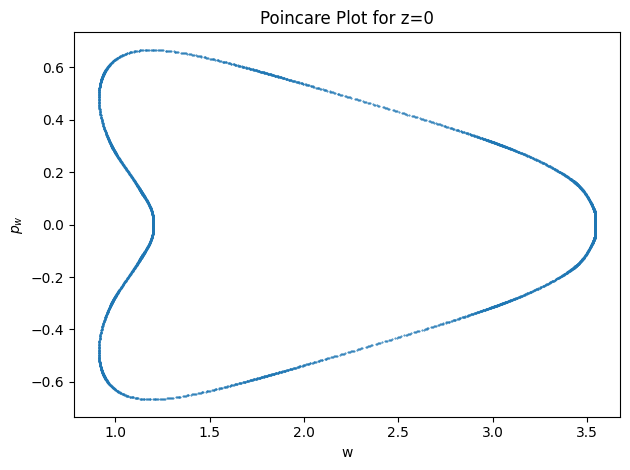

In [10]:
# * Poincare Plot

plt.scatter(sol.y_events[0][mask, 0], sol.y_events[0][mask, 3], s=0.2)
plt.title(r"Poincare Plot for z=0")
plt.xlabel(r"w")
plt.ylabel(r"$p_w$")
plt.tight_layout()
plt.savefig("poincare.png",dpi=300)

In [11]:
energy = H(mu, sol.y.T, alpha=alpha)  # Get the energy of given solutions

Text(0, 0.5, 'Energy')

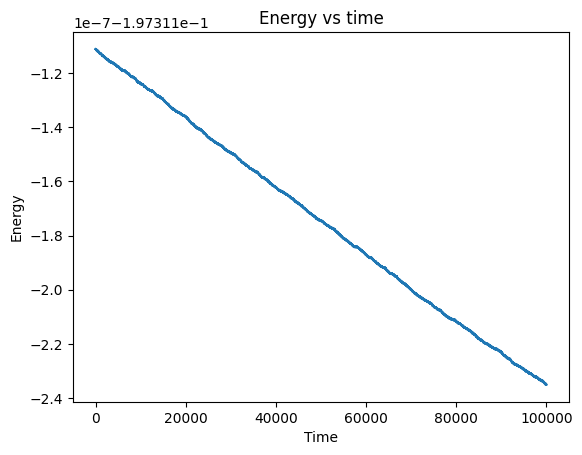

In [12]:
plt.plot(energy)
plt.title("Energy vs time")
plt.xlabel("Time")
plt.ylabel("Energy")

In [13]:
def chaotic_lyp(t, Y, alpha=alpha):
    """
    Function for solving the system of equation simultaneously with
    the Jacobian

    """

    # First system of equations

    w, z, phi, pw, pz, pphi = Y[:6]
    dw = pw
    dz = pz
    dphi = L / (mu * w**2)

    dpw = -mu * (-(L**2) / ((mu**2) * w**3) + M * w / ((w**2 + z**2) ** (3 / 2)))
    dpz = -mu * (M * z / ((w**2 + z**2) ** (3 / 2)) + alpha * np.tanh(z / z0))
    dpphi = 0.0

    dhdwdw = -mu * (
        3 * L**2 / ((mu**2) * (w**4))
        - 3 * M * w**2 / ((w**2 + z**2) ** (5 / 2))
        + M / ((w**2 + z**2) ** (3 / 2))
    )
    dhdwdz = 3 * M * mu * w * z / ((w**2 + z**2) ** (5 / 2))
    dhdzdz = -mu * (
        -3 * M * z**2 / ((w**2 + z**2) ** (5 / 2))
        + M / ((w**2 + z**2) ** (3 / 2))
        + alpha * (1 / (np.cosh(z / z0)) ** 2) / z0
    )

    # Now calculate the jacobian
    J = np.array(
        [
            [0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
            [-2 * L / (mu * w**3), 0.0, 0.0, 0.0, 0.0, 1 / (mu * w**2)],
            [dhdwdw, dhdwdz, 0.0, 0.0, 0.0, 2 * L / (mu * w**3)],
            [dhdwdz, dhdzdz, 0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        ]
    )

    dY = Y[6:].reshape((6, 1))
    dY_dt = np.dot(J, dY)

    return np.concatenate(([dw, dz, dphi, dpw, dpz, dpphi], dY_dt.flatten()))

In [14]:
#! Faster implementaton of above function
@nb.cfunc(lsoda_sig)
def faster_chaotic_system(t, u, du, p):
    """
    The same system as above but faster than above method. This uses Numba
    and Numbalsoda for faster evaluations
    """
    u_ = nb.carray(u, (12,))
    p_ = nb.carray(p, (1,))
    alpha = p_[0]
    w, z, phi, pw, pz, pphi = u_[:6]
    dw = pw
    dz = pz
    dphi = L / (mu * w**2)

    dpw = -mu * (-(L**2) / ((mu**2) * w**3) + M * w / ((w**2 + z**2) ** (3 / 2)))
    dpz = -mu * (M * z / ((w**2 + z**2) ** (3 / 2)) + alpha * np.tanh(z / z0))
    dpphi = 0.0

    dhdwdw = -mu * (
        3 * L**2 / ((mu**2) * w**4)
        - 3 * M * w**2 / ((w**2 + z**2) ** (5 / 2))
        + M / ((w**2 + z**2) ** (3 / 2))
    )
    dhdwdz = 3 * M * mu * w * z / ((w**2 + z**2) ** (5 / 2))
    dhdzdz = -mu * (
        -3 * M * z**2 / ((w**2 + z**2) ** (5 / 2))
        + M / ((w**2 + z**2) ** (3 / 2))
        + alpha * (1 / (np.cosh(z / z0)) ** 2) / z0
    )

    # Now calculate the jacobian

    J = np.array(
        [
            [0.0, 0.0, 0.0, 1.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
            [-2 * L / (mu * w**3), 0.0, 0.0, 0.0, 0.0, 1 / (mu * w**2)],
            [dhdwdw, dhdwdz, 0.0, 0.0, 0.0, 2 * L / (mu * w**3)],
            [dhdwdz, dhdzdz, 0.0, 0.0, 0.0, 0.0],
            [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
        ]
    )

    dY = u_[6:].reshape((6, 1))
    dY_dt = np.dot(J, dY)
    dydtf = dY_dt.flatten()
    du_ = np.zeros((12,), dtype=nb.float64)
    du_[:6] = np.array([dw, dz, dphi, dpw, dpz, dpphi])
    du_[6:] = dydtf

    for i in range(len(du_)):
        du[i] = du_[i]

pfunctptr = faster_chaotic_system.address

In [15]:
u0 = np.copy(ics)  # Initial condition for x(0)
w0 = np.random.normal(0.0, 1.0, (6))
w0 = w0 / np.linalg.norm(w0)  # Initial unitary deviation vector w(0)

ics0 = np.array((u0, w0)).flatten()  # Combined Initial vector

In [16]:
@nb.njit
def evolve_lyap(ics0, tau, tf, alpha, steps, sanity_check=0):

    ti = 0.0  # * Initial Time
    timestep = np.arange(ti, tf, tau)  # * Time interval
    size = timestep.shape[0]

    X1t = np.zeros((size - 1))  # *Lyapunaov Exponents
    sum = 0.0
    ics = ics0.copy()  # *We do not want to change our initial conditions
    h = np.zeros(size - 1)  # *Check for energy
    sol = np.zeros((size, 6))
    sol[0, :] = ics[:6]
    # traj=np.zeros((steps,6),dtype=np.float64)

    for i in range(0, size - 1):
        timeint = np.linspace(
            timestep[i], timestep[i + 1], steps
        )  #!Our time interval with 10000 points between them

        usol_, _ = lsoda(
            pfunctptr,
            ics,
            t_eval=timeint,
            data=np.array((alpha)),
            rtol=1e-12,
            atol=1e-12,
            mxstep=100000,
        )  # * Solver
        if i == 0:
            traj = np.zeros_like(usol_)
            traj = usol_

        usol = usol_[-1]

        # Uncomment following line to use scipy solver and comment above two lines
        # usol=integrate.solve_ivp(chaotic_lyp_paper,[0.,tf],ics0,'LSODA',t_eval=timeint,atol=1e-10,rtol=1e-10).y[:,-1]

        xk = usol[:6]  # Orbit at t= tau
        wk = usol[6:]  # Deviations at t=tau

        # *---------------------The following algorithm is from the paper

        alphak = np.linalg.norm(wk)
        sum = sum + np.log(alphak)
        X1t[i] = sum / timestep[i + 1]
        wk0 = wk / alphak

        # *----------------------Lyapunaov Exponents calculated above
        #! Now for another time step. Set the current solution as the initial conditions for next time steps
        ics[:6] = xk
        ics[6:] = wk0

        #! ------------------------Sanity Check--------------------------
        # if sanity_check!=0:
        h[i] = H(mu, ics, alpha)  #! Current Energy
        sol[i + 1, :] = ics[:6]
        #! Comment above line if you do not want to perform the sanity check

    # if sanity_check!=0:
    #     return X1t,h,sol, traj

    return X1t, sol, h


_, sol_, traj_ = evolve_lyap(
    ics0, 10.0, 100.0, alpha, steps, 0
)  #!Run it for the first time so that numba understands the call signature

In [17]:
lyaps1 = evolve_lyap(ics0, tau, tf, alpha, steps)  # * Lyapunaov Exponents.

#! If you get a warning the t+h_=t on the next step, ignore it.

Text(0.5, 1.0, 'Energy difference')

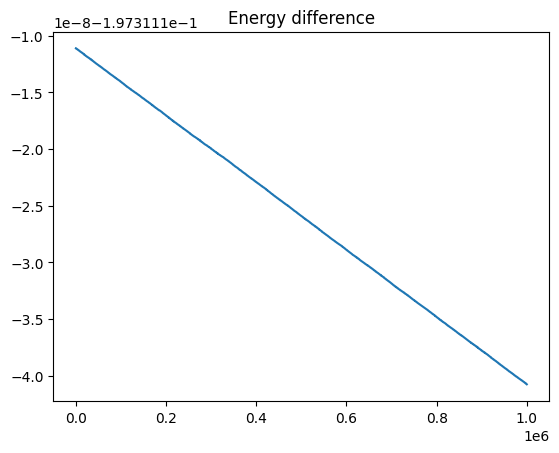

In [18]:
plt.plot(np.arange(0.0, tf, tau)[:-1], lyaps1[2])
plt.title("Energy difference")

In [19]:
np.mean(lyaps1[0][-10000:])

8.90451995415264e-05

Text(0.5, 1.0, 'Time Evolution of Lyapunov Exponents ')

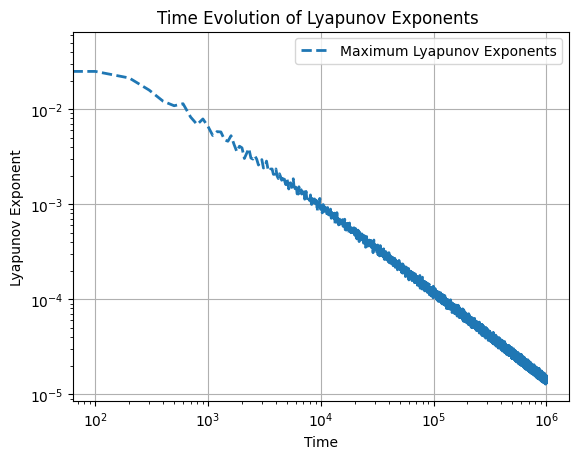

In [20]:
plt.figure()
plt.plot(
    np.arange(0.0, tf, tau)[:-2],
    lyaps1[0][:-1],
    label="Maximum Lyapunov Exponents",
    linewidth=2,
    linestyle="--",
)
ax = plt.gca()
ax.set_xscale("log", base=10)
ax.set_yscale("log", base=10)
plt.xlabel("Time")
plt.ylabel("Lyapunov Exponent")
plt.legend()
# plt.xlim(1e4,1e6)
plt.grid(True)
plt.title("Time Evolution of Lyapunov Exponents ")
# plt.show()

In [21]:
@nb.cfunc(lsoda_sig)
def faster_evolve(t, u, du, p):
    """
    Function for solving Differential Equation
    Args:
        t (float): Time Step
        x (np.ndarray): Shape (n,)

    Returns:
        Output (np.ndarray): Shape (n,)
    """
    # w,z, phi,pw,pz,pphi=x
    p_ = nb.carray(p, (1,))
    alpha = p_[0]
    du[0] = u[3]
    du[1] = u[4]
    du[2] = L / (mu * u[0] ** 2)

    du[3] = -mu * (
        -(L**2) / (mu**2 * u[0] ** 3) + M * u[0] / ((u[0] ** 2 + u[1] ** 2) ** (3 / 2))
    )
    du[4] = -mu * (
        M * u[1] / ((u[0] ** 2 + u[1] ** 2) ** (3 / 2)) + alpha * np.tanh(u[1] / z0)
    )
    du[5] = 0.0

funcptr = faster_evolve.address

In [22]:
@nb.njit(
    nb.float64[:](
        nb.float64,
        nb.float64[:, :],
        nb.float64,
        nb.float64,
        nb.float64,
        nb.float64,
        nb.float64,
    ),
    parallel=True,
)
def hplus(t, dH, R, mu, Theta, Psi, alpha):
    """

    Args:
        t ([float]): Time, not needed in this function
        dH ([ndarray]): Solution of differential Equation at various time steps, shape (n,6)
        R ([float]): Distance of observer and the system
        mu ([float]): Mass of the particle
        Theta ([float]): Location of the observer
        Psi ([float]): Location of the observer
        alpha ([float]): Parameter of the theory

    Returns:
        Expression of hplus ([ndarray]) at various time: Shape (n,6)
    """
    # Compute the hplus expression using NumPy

    r, zc, phi, pr, pzc, pphi = (
        dH[:, 0],
        dH[:, 1],
        dH[:, 2],
        dH[:, 3],
        dH[:, 4],
        dH[:, 5],
    )
    dr_dt = pr / mu
    dzc_dt = pzc / mu
    dPhi_dt = L / (mu**2 * r**2)
    d2r_dt2 = -(-(L**2) / (mu**2 * r**3) + M * r / ((r**2 + zc**2) ** (3 / 2)))
    d2zc_dt2 = -(M * zc / ((r**2 + zc**2) ** (3 / 2)) + alpha * np.tanh(zc / z0))
    d2Phi_dt2 = 0.0

    expression = (
        (1 / (2 * R))
        * mu
        * (
            -2
            * np.sin(Theta) ** 2
            * (dr_dt**2 - 2 * dzc_dt**2 + r * d2r_dt2 - 2 * zc * d2zc_dt2)
            + (3 + np.cos(2 * Theta))
            * np.sin(2 * phi)
            * (
                np.sin(2 * Psi) * (dr_dt**2 + r * (-2 * r * dPhi_dt**2 + d2r_dt2))
                - np.cos(2 * Psi) * r * (4 * dr_dt * dPhi_dt + r * d2Phi_dt2)
            )
            + (3 + np.cos(2 * Theta))
            * np.cos(2 * phi)
            * (
                np.cos(2 * Psi) * (dr_dt**2 + r * (-2 * r * dPhi_dt**2 + d2r_dt2))
                + r * np.sin(2 * Psi) * (4 * dr_dt * dPhi_dt + r * d2Phi_dt2)
            )
            + 2
            * np.sin(2 * Theta)
            * np.sin(phi)
            * (
                -np.sin(Psi)
                * (
                    2 * dr_dt * dzc_dt
                    + zc * d2r_dt2
                    + r * (-zc * dPhi_dt**2 + d2zc_dt2)
                )
                + np.cos(Psi)
                * (2 * (zc * dr_dt + r * dzc_dt) * dPhi_dt + r * zc * d2Phi_dt2)
            )
            - 2
            * np.cos(phi)
            * np.sin(2 * Theta)
            * (
                np.cos(Psi)
                * (
                    2 * dr_dt * dzc_dt
                    + zc * d2r_dt2
                    + r * (-zc * dPhi_dt**2 + d2zc_dt2)
                )
                + np.sin(Psi)
                * (2 * (zc * dr_dt + r * dzc_dt) * dPhi_dt + r * zc * d2Phi_dt2)
            )
        )
    )

    return expression

In [23]:
# @snoop
@nb.njit(
    nb.float64[:](
        nb.float64,
        nb.float64[:, :],
        nb.float64,
        nb.float64,
        nb.float64,
        nb.float64,
        nb.float64,
    ),
    parallel=True,
)
# Define the Python function 'hcross'
def hcross(t, dH, R, mu, Theta, Psi, alpha):
    """

    Args:
        t ([float]): Time, not needed in this function
        dH ([ndarray]): Solution of differential Equation at various time steps, shape (n,6)
        R ([float]): Distance of observer and the system
        mu ([float]): Mass of the particle
        Theta ([float]): Location of the observer
        Psi ([float]): Location of the observer
        alpha ([float]): Parameter of the theory

    Returns:
        Expression of hcross ([ndarray]) at various time: Shape (n,6)
    """
    # Compute the hcross expression using NumPy

    r, zc, phi, pr, pzc, pphi = (
        dH[:, 0],
        dH[:, 1],
        dH[:, 2],
        dH[:, 3],
        dH[:, 4],
        dH[:, 5],
    )
    dr_dt = pr
    dzc_dt = pzc
    dPhi_dt = L / (mu * r**2)
    d2r_dt2 = -mu * (-(L**2) / (mu**2 * r**3) + M * r / ((r**2 + zc**2) ** (3 / 2)))
    d2zc_dt2 = -mu * (M * zc / ((r**2 + zc**2) ** (3 / 2)) + alpha * np.tanh(zc / z0))
    d2Phi_dt2 = 0.0

    # Compute the expression using NumPy
    expression = (
        (1 / R)
        * 2
        * mu
        * (
            -np.cos(Theta) * np.sin(2 * (Psi - phi)) * dr_dt**2
            + 2
            * dr_dt
            * (
                np.sin(Theta) * np.sin(Psi - phi) * dzc_dt
                + (
                    2 * np.cos(Theta) * np.cos(2 * (Psi - phi)) * r
                    - np.cos(Psi - phi) * np.sin(Theta) * zc
                )
                * dPhi_dt
            )
            + np.cos(Theta)
            * r
            * (
                np.sin(2 * (Psi - phi)) * (2 * r * dPhi_dt**2 - d2r_dt2)
                + np.cos(2 * (Psi - phi)) * r * d2Phi_dt2
            )
            + np.sin(Theta)
            * (
                np.sin(Psi - phi) * zc * d2r_dt2
                - r
                * (
                    2 * np.cos(Psi - phi) * dzc_dt * dPhi_dt
                    + np.sin(Psi - phi) * (zc * dPhi_dt**2 - d2zc_dt2)
                    + np.cos(Psi - phi) * zc * d2Phi_dt2
                )
            )
        )
    )

    return expression

In [24]:
# Solve the system
usol10, success = lsoda(
    funcptr, ics, tm2, data=np.array((alpha)), atol=1e-12, rtol=1e-12
)

In [25]:
hp10 = hplus(0, usol10, R, mu, Theta, Psi, alpha)  # hplus
hc10 = hcross(0, usol10, R, mu, Theta, Psi, alpha)  # hcross

Text(0.5, 0, 't')

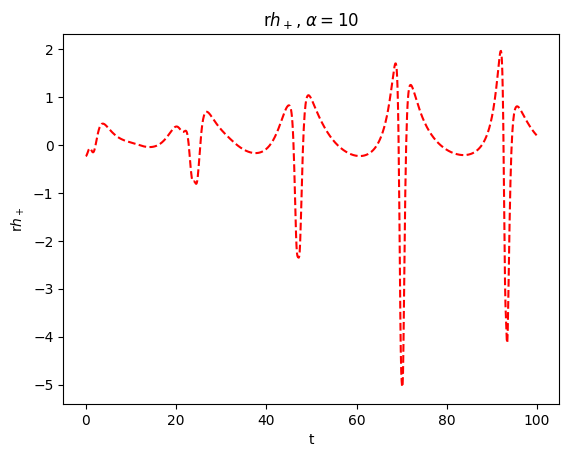

In [26]:
fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2[:1000], R * hp10[:1000], "r--")
plt.title(r"r$h_+$, $\alpha=10$")
plt.ylabel(r"r$h_+$")
plt.xlabel("t")

Text(0.5, 0, 't')

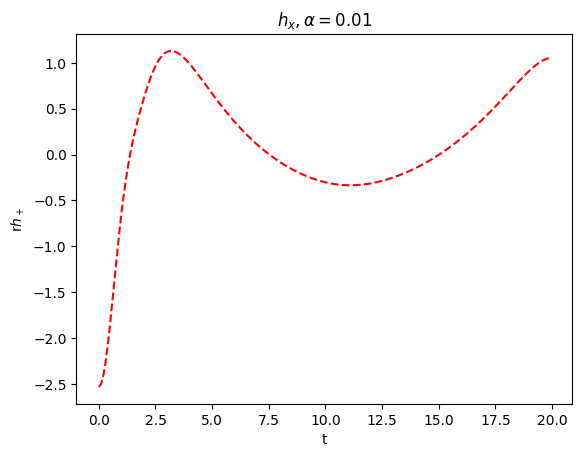

In [27]:
fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2[:200], R * hc10[:200], "r--")
plt.title(r"$h_x, \alpha=${0}".format(alpha))
plt.ylabel(r"r$h_+$")
plt.xlabel("t")

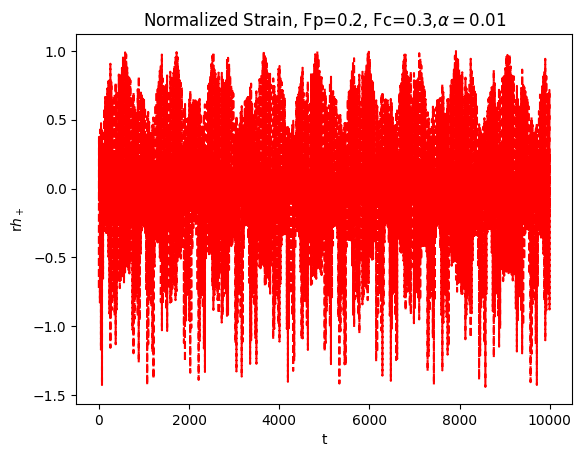

In [28]:
norm_strain = (R * (Fp * hp10 + Fc * hc10)) / np.max((R * (Fp * hp10 + Fc * hc10)))

fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2, norm_strain, "r--")
plt.title(r"Normalized Strain, Fp=0.2, Fc=0.3,$\alpha=0.01$")
plt.ylabel(r"r$h_+$")
plt.xlabel("t")
plt.savefig("Normalized_Strain.png",dpi=300)

In [29]:
def de_dw(t, hp, hc):
    """
    Calculate dE/dw

    Args:
        t (ndarray): Time array between which to calculate the FFT, Shape: (n,)
        hp (ndarray): hplus array, Shape: (n,)
        hc (ndarray): hcross array, Shape: (n,)

    Returns:
        dEdw (ndarray): dEdw, shape(n//2,)
        df (ndarray): Fourier Transform Frequencies, shape(n//2,)
    """
    # window=np.hanning(t.size)
    fhp = np.fft.fft(hp, norm="ortho")
    fhc = np.fft.fft(hc, norm="ortho")
    N = len(fhc)

    dt = t[1] - t[0]
    # df=sp.fft.fftfreq(len(fhp),dt)[1:N//2]
    df = (np.arange(len(t)) / (dt * N))[: N // 2]
    # const=(3e8)**3/(4*6.674e-11)

    E = (np.abs(fhp) ** 2 + np.abs(fhc) ** 2)[: N // 2]
    dEdw = (E * df**2) * R**2

    return dEdw, df

In [30]:
E10, f10 = de_dw(tm2, hp10, hc10)
# * For alpha

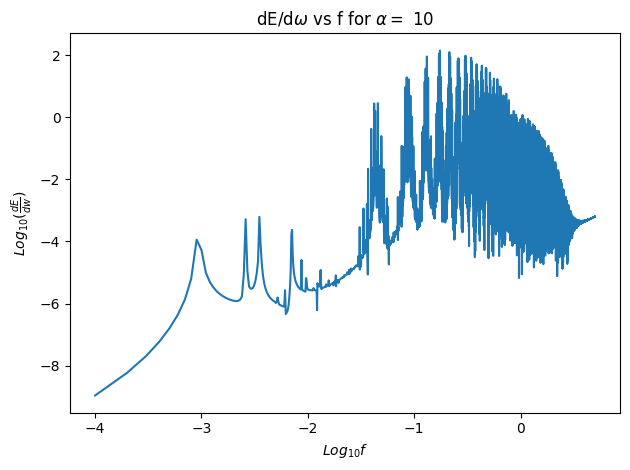

In [31]:
plt.plot(np.log10(f10[1:]), np.log10(E10[1:]))
plt.title(r"dE/d$\omega$ vs f for $\alpha=$ 10")
plt.ylabel(r"$Log_{10}(\frac{dE}{dw}$)")
plt.xlabel(r"$Log_{10}f$")
plt.tight_layout()
plt.savefig("Energy_density.png",dpi=300)

In [32]:
#! Noise + Signal

noise = np.random.normal(0.0, 1.0, len(hp10))  # * Normally distributed Random Noise

nhp10 = hp10 + noise  # *Adding noise to signals
nhc10 = hc10 + noise

# nhp10=nhp10/np.max(nhp10)
# nhc10 = nhc10 / np.max(nhc10)

Text(0.5, 0, 't')

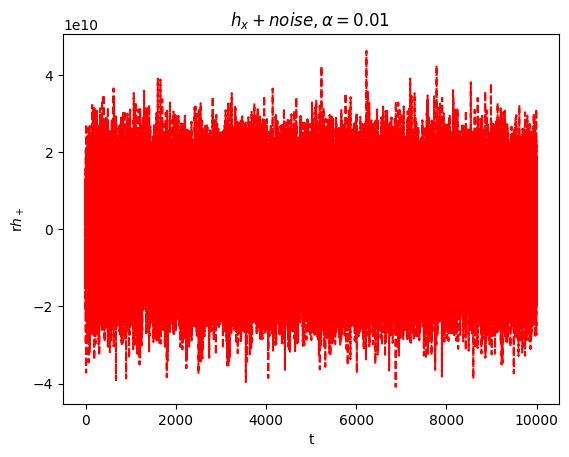

In [33]:
fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2, R * nhc10, "r--")
plt.title(r"$h_x+ noise, \alpha=0.01$ ")
plt.ylabel(r"r$h_+$")
plt.xlabel("t")

Text(0.5, 0, 't')

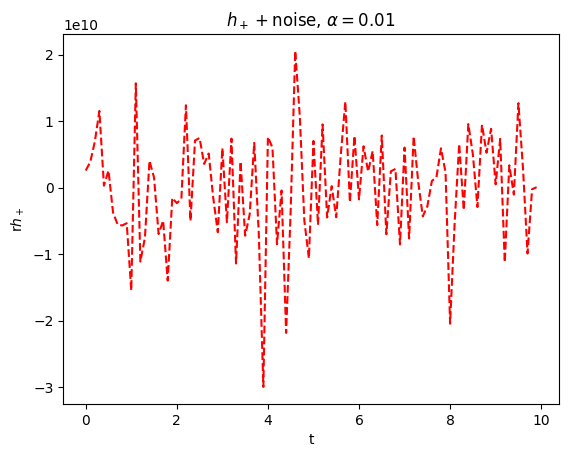

In [34]:
fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2[:100], R * nhp10[:100], "r--")
plt.title(r"$h_++$noise, $\alpha=0.01$")
plt.ylabel(r"r$h_+$")
plt.xlabel("t")

In [35]:
norm_strain_noise = (R * (Fp * nhp10 + Fc * nhc10)) / np.max((R * (Fp * nhp10 + Fc * nhc10)))

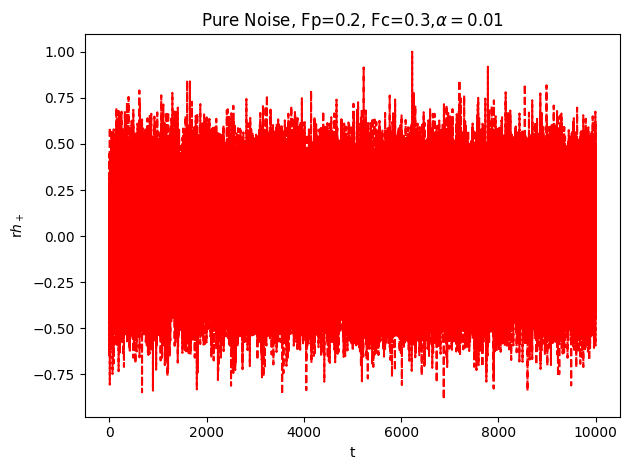

In [36]:
fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2, R *noise/(np.max(R*noise)), "r--")
plt.title(r"Pure Noise, Fp=0.2, Fc=0.3,$\alpha=0.01$")
plt.ylabel(r"r$h_+$")
plt.xlabel("t")
plt.tight_layout()
plt.savefig("pure_noise.png",dpi=300)

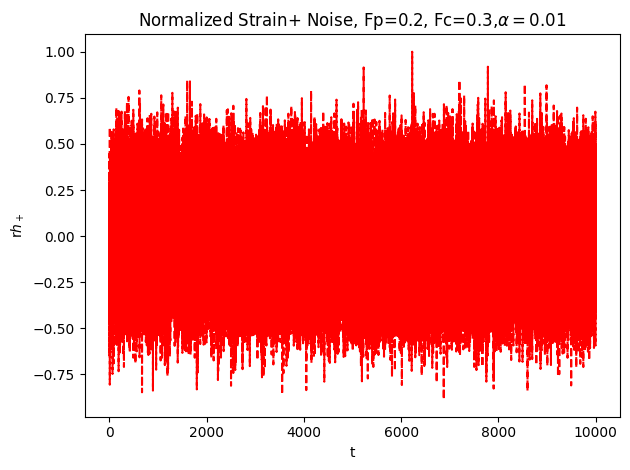

In [37]:
fig = plt.figure()
# fig.set_size_inches(10.5, 10.5)
plt.plot(tm2,norm_strain_noise, "r--")
plt.title(r"Normalized Strain+ Noise, Fp=0.2, Fc=0.3,$\alpha=0.01$")
plt.ylabel(r"r$h_+$")
plt.xlabel("t")
plt.tight_layout()
plt.savefig("strain_noise.png",dpi=300)

In [38]:
#! Get the energy spectra for noise with signals
NE10, nf10 = de_dw(tm2, nhp10, nhc10)

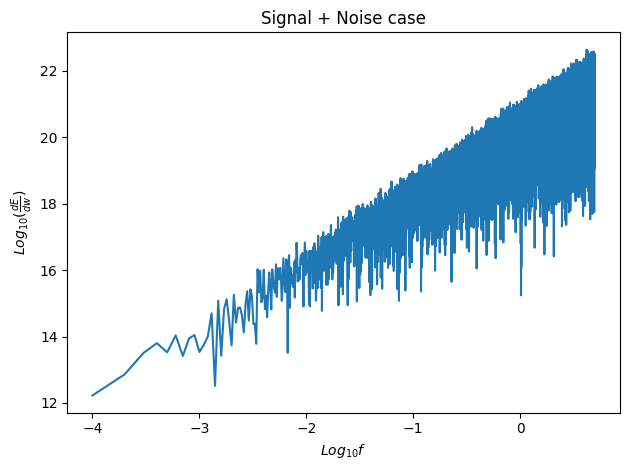

In [39]:
fig, ax = plt.subplots(nrows=1, ncols=1)
# fig.set_size_inches(18.5, 10.5)
ax.plot(np.log10(nf10[1:]), np.log10(NE10[1:]))

# fig.suptitle(r"dE/d$\omega$ vs f for $\alpha=10.$")
ax.set_title("Signal + Noise case")

plt.ylabel(r"$Log_{10}(\frac{dE}{dw}$)")
plt.xlabel(r"$Log_{10}f$")
plt.tight_layout()
plt.savefig("psd_signal_noise.png",dpi=300)

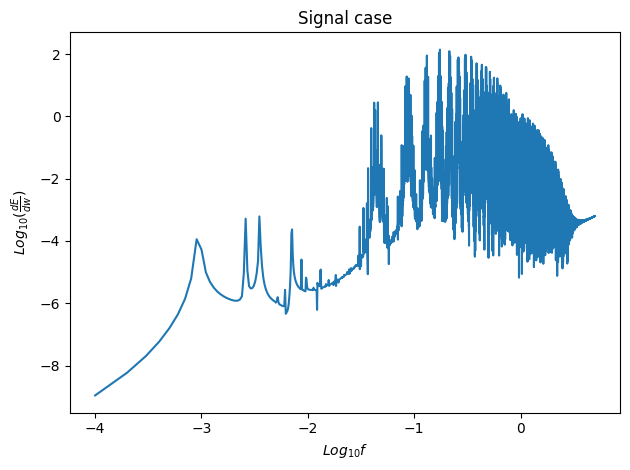

In [40]:
fig, ax = plt.subplots(nrows=1, ncols=1)
ax.plot(np.log10(f10[1:]), np.log10(E10[1:]))
ax.set_title("Signal case")
plt.ylabel(r"$Log_{10}(\frac{dE}{dw}$)")
plt.xlabel(r"$Log_{10}f$")
plt.tight_layout()
plt.savefig("psd_signal.png", dpi=300)

In [41]:
# import pycbc.psd 
# import pycbc.noise
# from pycbc.types import TimeSeries, FrequencySeries
# from pycbc.psd import interpolate, inverse_spectrum_truncation
# from pycbc.filter import matched_filter

# import legwork
# import astropy
# import astropy.units as u
# from importlib import resources
# import psd

In [42]:
## Noise level in the Science Requirement Document
sqSnoise_SciRD = [3e-15, 15e-12]

## Speed of light
c = 299792458.0

## Year in seconds
year = 31558149.763545603

## Astronomical Unit in seconds
AUs = 499.00478383615643

## Armlength in seconds
L_m = 2.5e9
L = L_m / c

In [43]:
def PSD_Noise_components(fr, sqSnoise):
    [sqSacc_level, sqSoms_level] = sqSnoise
    # sqSacc_level: Amplitude level of acceleration noise [3e-15]
    # sqSoms_level: Amplitude level of OMS noise [15e-12]

    ### Acceleration noise
    Sa_a = sqSacc_level**2 * (1.0 + (0.4e-3 / fr) ** 2) * (1.0 + (fr / 8e-3) ** 4)
    Sa_d = Sa_a * (2.0 * np.pi * fr) ** (-4.0)
    Sa_nu = Sa_d * (2.0 * np.pi * fr / c) ** 2

    ### Optical Metrology System
    Soms_d = sqSoms_level**2 * (1.0 + (2.0e-3 / fr) ** 4)
    Soms_nu = Soms_d * (2.0 * np.pi * fr / c) ** 2

    return [Sa_nu, Soms_nu]

In [44]:
def PSD_Noise_X20(fr, sqSnoise):
    #! This gives S_n for X_{2.0} as described in Eq 120 in LISA SciRD
    [Sa_nu,Soms_nu] = PSD_Noise_components(fr, sqSnoise)
    phiL = 2*np.pi*fr*L
    return 64 * (np.sin(phiL))**2 * ( np.sin(2*phiL))**2 * (Soms_nu + Sa_nu*(3+np.cos(2*phiL)) )

In [45]:
# Tobs_str = "1e6"  # Duration
# Tobs = float(Tobs_str)

# fOrb_kep = "./orbits_keplerian.h5"
# fOrb_kep_up = fOrb_kep[:-3] + "_up.h5"


# OMSNoise_dnon = sqSnoise_SciRD[1]/c
# fNNoiseLN20Full = f"./LN_Sim_LISA_{Tobs_str}_NoiseOnly_TDI20_SciRDv1.h5"
# print(f'To run LISANode :\n\
#  1. Use version 1.2 (https://gitlab.in2p3.fr/j2b.bayle/LISANode/-/releases/v1.2)\n\
#  2. Change in the config.py LISA_ACC_NOISE_A_LEVEL = {sqSnoise_SciRD[0]}\n\
#  3. Change in the config.py TDI_GENERATION = 2.0\n\
#  4. Run :\n\
# lisanode run lisanode:LISAWithTDI \
# --duration={Tobs_str} \
# --lasernoise-on-off=0 \
# --backlinknoise-on-off=0 \
# --accelnoise-on-off=1 \
# --readoutnoise-on-off=1 \
# --obpathlengthnoise-on-off=0 \
# --telescopenoise-on-off=1 \
# --rangingnoise-on-off=0 \
# --usonoise-on-off=0 \
# --modulationnoise-on-off=0 \
# --readoutnoise-isc-c-gain={OMSNoise_dnon} \
# --readoutnoise-isc-sb-gain=0.0 \
# --readoutnoise-tm-c-gain=0.0 \
# --readoutnoise-ref-c-gain=0.0 \
# --readoutnoise-ref-sb-gain=0.0 \
# --orbit-path={fOrb_kep_up} \
# --output="{fNNoiseLN20Full}"')
# fNNoiseLN20=fNNoiseLN20Full[:-3]+"_red.h5"

In [46]:
# psdNoiseLN20 = psd.Series.from_file(fNNoiseLN20 + ":X", skiprows=200)
# psdNoiseLN20[0].compute(nperseg=200000)

# plt.figure()
# plt.plot(psdNoiseLN20[0].times, psdNoiseLN20[0].data)
# plt.xlabel("time (s)")
# plt.title("Noise for TDI=2.0 using precomputed data")

# plt.figure()
# psdNoiseLN20[0].plot()

In [47]:
## Minimal frequency for plotting
fMin = 1e-5

## Minimal frequency for plotting
fMax = 1

fr = 10 ** np.arange(np.log10(fMin), np.log10(fMax), 0.002)

In [48]:
# Soms = (15e-12) ** 2 * (1 + (2e-3 / fr) ** 4)
# Sacc = (3e-15) ** 2 * (1 + (4e-4 / fr) ** 2) * (1 + (fr / 8e-3) ** 4)
# Cf = 16 * (np.sin(2 * np.pi * fr * L)) ** 2 * (np.sin(4 * np.pi * fr * L)) ** 2
# SX_MRD = (
#     4 * Cf * (Soms + (3 + np.cos(4 * np.pi * fr * L)) * Sacc / (2 * np.pi * fr) ** 4)
# )

# plt.figure()
# plt.loglog(
#     fr, PSD_Noise_X20(fr, sqSnoise_SciRD) * (c / (2 * np.pi * fr)) ** 2, label="Ref"
# )
# plt.loglog(fr, SX_MRD, "--", label="MRD")
# plt.xlabel(r"Frequency ($Hz$)")
# plt.ylabel(r"PSD noise $X_{2.0}$ ($m^2/{Hz}$)")
# plt.xlim([fMin, fMax])
# plt.ylim([1e-23, 1e-19])
# plt.grid()
# plt.legend()

# plt.figure()
# plt.loglog(
#     fr, SX_MRD / (PSD_Noise_X20(fr, sqSnoise_SciRD) * (c / (2 * np.pi * fr)) ** 2)
# )
# plt.xlabel(r"Frequency ($Hz$)")
# plt.ylabel(r"Ratio")
# plt.xlim([fMin, fMax])
# plt.grid()

In [49]:
# def LISAmotion(tm):

#     lamb = 0.0
#     kappa = 0.0

#     N = len(tm)

#     a = AUs
#     e = L / (2.0 * np.sqrt(3.0) * a)
#     # print ("orbital eccentricity", e)
#     nn = np.array([1, 2, 3])

#     Beta = (nn - 1) * 2.0 * np.pi / 3.0 + lamb
#     alpha = 2.0 * np.pi * tm / year + kappa

#     x = np.zeros((3, N))
#     y = np.zeros((3, N))
#     z = np.zeros((3, N))
#     for i in range(3):
#         x[i, :] = a * np.cos(alpha) + a * e * (
#             np.sin(alpha) * np.cos(alpha) * np.sin(Beta[i])
#             - (1.0 + (np.sin(alpha)) ** 2) * np.cos(Beta[i])
#         )
#         y[i, :] = a * np.sin(alpha) + a * e * (
#             np.sin(alpha) * np.cos(alpha) * np.cos(Beta[i])
#             - (1.0 + (np.cos(alpha)) ** 2) * np.sin(Beta[i])
#         )
#         z[i, :] = -np.sqrt(3.0) * a * e * np.cos(alpha - Beta[i])

#     ### I just need links
#     n23 = np.array([x[1, :] - x[2, :], y[1, :] - y[2, :], z[1, :] - z[2, :]]) / L
#     n31 = np.array([x[2, :] - x[0, :], y[2, :] - y[0, :], z[2, :] - z[0, :]]) / L
#     n12 = np.array([x[0, :] - x[1, :], y[0, :] - y[1, :], z[0, :] - z[1, :]]) / L

#     return (n23, n31, n12)

Functions defined in section 4 of the TN, equations (33) and (34)
Equations (34): beam patterns orbital companent
$$
\Upsilon_{rs} = Sinc\left[  \frac{\omega L}{2} 
(1 - \hat{k}.\hat{n}{rs})\right]
e^{-i  \frac{\omega L}{2} 
    (1 - \hat{k}.\hat{n}{rs})} + Sinc\left[  \frac{\omega L}{2} 
(1 - \hat{k}.\hat{n}{sr})\right]
e^{-i  \frac{\omega L}{2} 
(3 + \hat{k}.\hat{n}{sr})}
$$

In [50]:
# def Psi(lam, bet, n):
#     ### direction of GW propagation
#     k = -1.0 * np.array(
#         [np.cos(bet) * np.cos(lam), np.cos(bet) * np.sin(lam), np.sin(bet)]
#     )

#     kn = np.dot(k, n)

#     x = om * L

#     Gam_rs = np.sinc((1.0 - kn) * 0.5 * x / np.pi) * np.exp(-0.5j * x * (1.0 - kn))
#     Gam_sr = np.sinc((1.0 + kn) * 0.5 * x / np.pi) * np.exp(-0.5j * x * (1.0 + kn))

#     Psi_rs = Gam_rs + Gam_sr * np.exp(-1.0j * x * (1 - kn))

#     return Psi_rs

Equations (33): beam patterns polarisation components 
$$
F_{rs}^+​=n^i_{rs}​n^j_{rs}​[ϵ_{ij}^+​cos2ψ+ϵ_{ij}^×​sin2ψ]\\
\left[\epsilon^{+}_{ij} \sin{2 \psi} +  \epsilon^{\times}_{ij} \cos{2\psi}\right]
$$

In [51]:
# def Fp_rs(psi, lam, bet, n):

#     u = np.array([np.sin(lam), -np.cos(lam), 0.0])
#     v = np.array([-np.sin(bet) * np.cos(lam), -np.sin(bet) * np.sin(lam), np.cos(bet)])

#     nu = np.dot(u, n)
#     nv = np.dot(v, n)

#     plus = nu * nu - nv * nv
#     cros = 2.0 * nu * nv

#     Fp = np.cos(psi) * plus + np.sin(psi) * cros

#     return Fp


# def Fc_rs(psi, lam, bet, n):

#     u = np.array([np.sin(lam), -np.cos(lam), 0.0])
#     v = np.array([-np.sin(bet) * np.cos(lam), -np.sin(bet) * np.sin(lam), np.cos(bet)])

#     nu = np.dot(u, n)
#     nv = np.dot(v, n)

#     plus = nu * nu - nv * nv
#     cros = 2.0 * nu * nv

#     Fc = -np.sin(psi) * plus + np.cos(psi) * cros

#     return Fc

Then the components of equations (35) ($\times 4$):
$$
4 F^{+}_{X} \equiv  \left[ F_{13}^{+}\Upsilon_{13} - F_{12}^{+}\Upsilon_{12}\right]
$$
$$
4 F^{\times}_X \equiv  \left[ F_{13}^{\times}\Upsilon_{13} - F_{12}^{\times}\Upsilon_{12} \right]
$$

In [52]:
# def XPlus(psi, lam, bet):
#     F13 = Fp_rs(psi, lam, bet, -n31[:, ti])
#     F12 = Fp_rs(psi, lam, bet, n12[:, ti])

#     Psi13 = Psi(lam, bet, -n31[:, ti])
#     Psi12 = Psi(lam, bet, n12[:, ti])

#     return (F13*Psi13 - F12*Psi12)


# def XCros(psi, lam, bet):
#     F13 = Fc_rs(psi, lam, bet, -n31[:, ti])
#     F12 = Fc_rs(psi, lam, bet, n12[:, ti])

#     Psi13 = Psi(lam, bet, -n31[:, ti])
#     Psi12 = Psi(lam, bet, n12[:, ti])

#     return (F13*Psi13 - F12*Psi12)

In [53]:
freqs, AvFXp2_Raw = np.load("./AvFXp2_Raw.npy")

In [54]:
# plt.figure()
# plt.semilogx(freqs, AvFXp2_Raw, "o-")
# plt.xlabel(r"Frequency ($Hz$)")
# plt.ylabel(r"$<(F^{+}_{X})^2>$")
# plt.grid()

# plt.figure()
# plt.semilogx((2.0 * np.pi * freqs * L), AvFXp2_Raw, "o-")
# plt.xlabel(r"$\omega L$")
# plt.ylabel(r"$<(F^{+}_{X})^2>$")
# plt.grid()

In [55]:
from scipy.interpolate import InterpolatedUnivariateSpline as spline
AvFXp2 = np.interp(fr,freqs,AvFXp2_Raw)

In [56]:
# RXSAX20 = (
#     (2 * np.pi * fr * (L_m / c)) ** 2
#     * (np.sin(2 * np.pi * fr * L)) ** 2
#     * (2 * np.sin(2 * 2 * np.pi * fr * L)) ** 2
#     * AvFXp2
# )

In [57]:
# plt.figure()
# plt.loglog(fr, RXSAX20, label="X2.0")
# plt.xlabel("Frequency (Hz)")
# plt.ylabel("Response to GW")
# plt.legend()
# plt.grid()

In [58]:
[Sa_nu, Soms_nu] = PSD_Noise_components(fr, sqSnoise_SciRD)
phiL = 2 * np.pi * fr * L
S_hX_SA = (Soms_nu + Sa_nu * (3 + np.cos(2 * phiL))) / (phiL**2 * AvFXp2 / 4**2)
S_h_SA = S_hX_SA / 2

In [59]:
def GenGal(fr, Tobs, A, f2, alp, a1, b1, ak, bk):

    f1 = 10**(a1*np.log10(Tobs) + b1)
    fk = 10**(ak*np.log10(Tobs) + bk)

    Sgal = 0.5*A*fr**(-7./3.)*np.exp(-(fr/f1)**alp)* (1.0 + np.tanh((fk - fr)/f2) )

    return (Sgal)

In [60]:
# tts = [0.5, 1.0, 4.0]

# plt.figure()
# plt.loglog(fr, S_hX_SA, 'k')
# for Tobs in tts:
#     print ('Tobs = ', Tobs)
#     Snik_mean = GenGal(fr, Tobs, 1.14e-44, 0.31e-3, 1.8, -0.25, -2.7, -0.27, -2.47)
#     plt.loglog(fr, S_hX_SA+Snik_mean, lw=2, label=f'Tobs = {Tobs} yrs')
    

# plt.xlabel(r'Frequency ($Hz$)')
# plt.ylabel(r'$\sqrt{S_{h,X}}$ : Sensitivity TDI X 4 links $\left(1/\sqrt{Hz}\right)$')
# plt.xlim([2.e-4, 1e-2])
# plt.ylim([1.e-40, 1.e-34])
# plt.grid()
# plt.legend()
# plt.title("Galactic Confusion Noise Sensitivity")

In [61]:
fr= 10**np.linspace(np.log10(fMin),np.log10(fMax),100000)

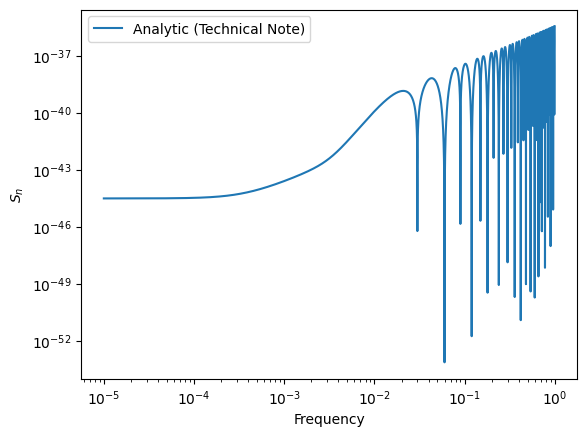

In [62]:
plt.loglog(fr, PSD_Noise_X20(fr, sqSnoise_SciRD), label="Analytic (Technical Note)")
plt.xlabel("Frequency")
plt.ylabel("$S_n$")
plt.legend()
plt.savefig("psd_lisa.png")

In [63]:
# lisa_psd = PSD_Noise_X20(fr, sqSnoise_SciRD)

In [64]:
AvFXp2 = np.interp(fr, freqs, AvFXp2_Raw)
[Sa_nu, Soms_nu] = PSD_Noise_components(fr, sqSnoise_SciRD)
phiL = 2 * np.pi * fr * L
S_hX_SA = (Soms_nu + Sa_nu * (3 + np.cos(2 * phiL))) / (phiL**2 * AvFXp2 / 4**2)
S_h_SA = S_hX_SA / 2

In [65]:
S_gal = GenGal(fr, 4, 1.14e-44, 0.31e-3, 1.8, -0.25, -2.7, -0.27, -2.47)

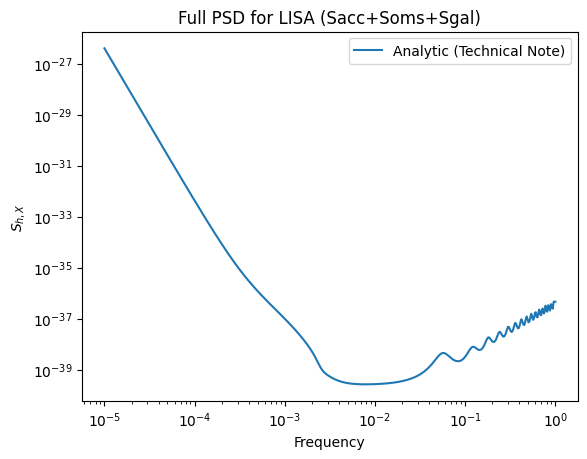

In [66]:
plt.loglog(fr, S_hX_SA+S_gal, label="Analytic (Technical Note)")
plt.xlabel("Frequency")
plt.ylabel("$S_{h,X}$")
plt.legend()
plt.title("Full PSD for LISA (Sacc+Soms+Sgal)")
plt.savefig("psd_lisa.png")

In [67]:
log_fr= np.log(fr)
log_psds= np.log(S_hX_SA)

In [68]:
def colour(f):
    with np.errstate(divide="ignore"):
        return np.exp(np.interp(np.log(f), log_fr, log_psds))

In [69]:
n, dt = 100000, 1 / 16.0
f = np.fft.rfftfreq(n, dt)
rng = np.random.default_rng()
x_f = rng.normal(0,0.5, len(f)) + 1j * rng.normal(0, 0.5, len(f))
x_f *= np.sqrt(n / dt)

x_f[0] = np.abs(x_f[0])
if len(f) % 2 == 0:
    x_f[-1] = np.abs(x_f[-1])
x_f *= np.sqrt(colour(f))
noise= np.fft.irfft(x_f)

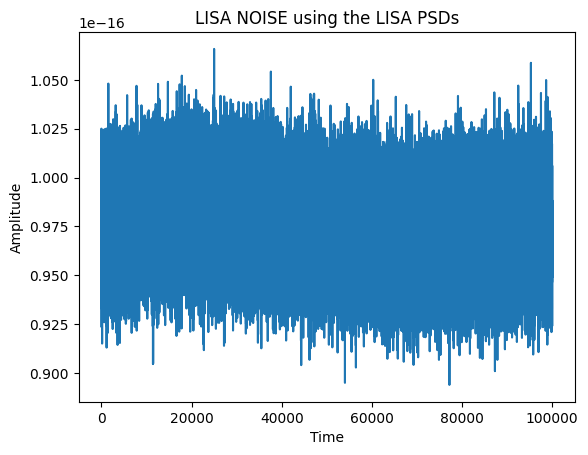

In [70]:
plt.plot(noise)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("LISA NOISE using the LISA PSDs")
plt.savefig("noise_lisa.png")

# Let us add our signal to the noise above

In [71]:
lower= -1.
upper= 1.

In [72]:
def normalize(
    x, newRange=(0, 1)
):  # x is an array. Default range is between zero and one
    xmin, xmax = np.min(x), np.max(x)  # get max and min from input array
    norm = (x - xmin) / (xmax - xmin)  # scale between zero and one

    if newRange == (0, 1):
        return norm  # wanted range is the same as norm
    elif newRange != (0, 1):
        return (
            norm * (newRange[1] - newRange[0]) + newRange[0]
        )  # scale to a different range.
    # add other conditions here. For example, an error message

In [73]:
Nhp10= normalize(hp10,(-1e-21,1e-21))
Nhc10 = normalize(hc10, (-1e-21, 1e-21))

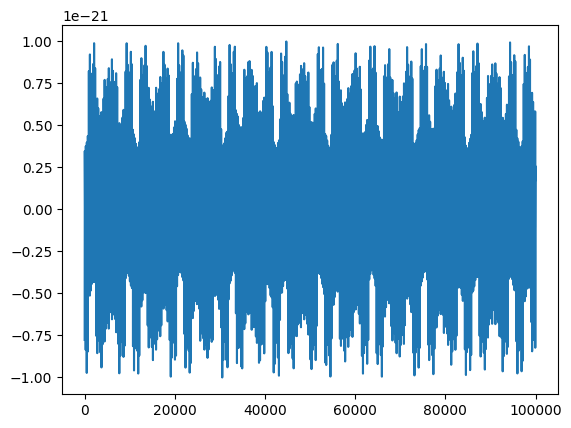

In [74]:
plt.plot(Nhc10)

In [75]:
lnoise= noise.copy()
# lnoise = psdNoiseLN20[0].data.copy()

In [76]:
lnoise[10000:20000]= noise[10000:20000] + Nhp10[10000:20000]
# lnoise[10000:20000] = psdNoiseLN20[0].data[10000:20000] + Nhp10[10000:20000]

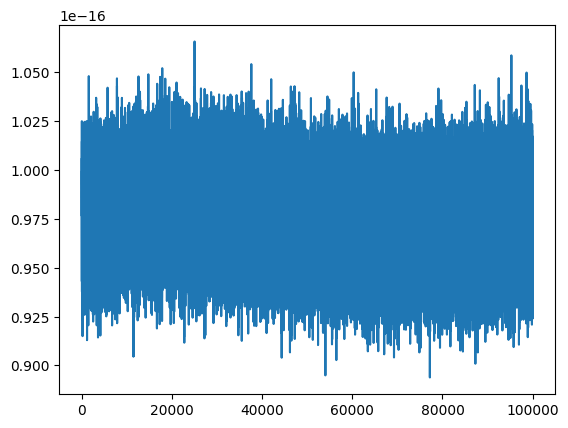

In [77]:
plt.plot(lnoise)
# plt.plot(lnoise[30000:40000])

In [78]:
# data= lnoise.copy()
# # template= Nhp10[50000:60000].copy()
# template= Nhp10+Nhc10
# # template= normalize(np.random.normal(0.,1.,10000),(-1e-21,1e-21))
# data_fft= np.fft.fft(lnoise)
# zero_pad = np.zeros(data.size - template.size)
# template_padded = np.append(template, zero_pad)
# template_fft = np.fft.fft(template_padded)

In [79]:
# plt.plot(data, label="data")
# plt.plot(
#     template_padded,
#     label="Sample Template",
# )
# plt.ylabel("Amplitude")
# plt.xlabel("Time")
# plt.title("Trial template with the signal")
# # plt.legend()
# # plt.savefig("GWdata_signal.png")

In [80]:
template_fft= abs(np.fft.fft(Nhp10))**2 + abs(np.fft.fft(Nhc10))**2
# template_fft = abs(
#     np.fft.fft(normalize(np.random.normal(0.0, 1.0, len(hp10)), (-1e-21, 1e-21)))
# ) ** 2 + abs(np.fft.fft(normalize(np.random.normal(0.0, 1.0, len(hp10)), (-1e-21, 1e-21))))**2
# template_fft= template_fft[1:]

In [81]:
dt=t[1]-t[0]
fr= np.fft.fftfreq(len(hp10),1/dt)
# (np.arange(len(t)+1) / (dt * N))[: N // 2 +1]

In [82]:
ind = np.argwhere(fr < 0.0)[0, 0]
pfr = fr[1 : ind]
template_fft = template_fft[1:ind]

In [83]:
pfr

array([1.0000e-05, 2.0000e-05, 3.0000e-05, ..., 4.9997e-01, 4.9998e-01,
       4.9999e-01])

In [84]:
SAv= np.interp(pfr, freqs,AvFXp2_Raw)

SRXSAX20 = (
    (2 * np.pi * pfr * (L_m / c)) ** 2
    * (np.sin(2 * np.pi * pfr * L)) ** 2
    * (2 * np.sin(2 * 2 * np.pi * pfr * L)) ** 2
    * SAv
)

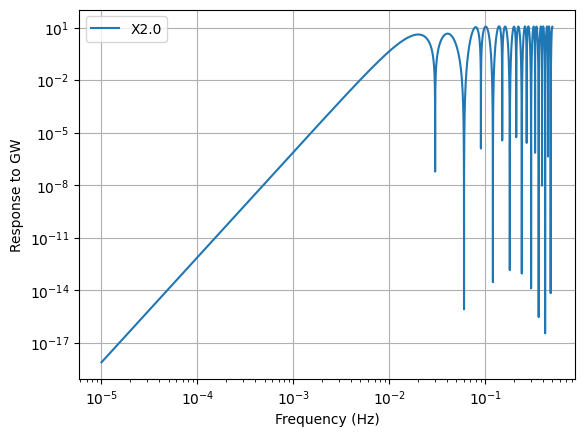

In [85]:
plt.figure()
plt.loglog(pfr, SRXSAX20, label="X2.0")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Response to GW")
plt.legend()
plt.grid()

In [86]:
[Sa_nu, Soms_nu] = PSD_Noise_components(pfr, sqSnoise_SciRD)
phiL = 2 * np.pi * pfr * L
S_hX_SA = (Soms_nu + Sa_nu * (3 + np.cos(2 * phiL))) / (phiL**2 * SAv / 4**2)
# S_h_SA = S_hX_SA / 2

In [87]:
noiseratio= (template_fft)/(S_hX_SA)

In [88]:
SNR=np.sqrt(np.trapz(noiseratio,pfr)*4)
display(SNR)

7.337561086872711